In [1]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\KIIT0001\miniconda3\envs\traffic-ml\python.exe
3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]


In [2]:
import os

data_folder = "../data"

print("Files in data folder:")
for file in os.listdir(data_folder):
    path = os.path.join(data_folder, file)
    size_gb = os.path.getsize(path) / (1024 ** 3)
    print(f"{file}  |  {size_gb:.2f} GB")

Files in data folder:
US_Accidents_March23.csv  |  2.85 GB


In [3]:
import pandas as pd

file_path = "../data/US_Accidents_March23.csv"

# Load only the first 1,000 rows
sample = pd.read_csv(file_path, nrows=1000)

print("Shape of sample:", sample.shape)

print("\nColumns:")
for i, col in enumerate(sample.columns, 1):
    print(f"{i}. {col}")

print("\nFirst 5 rows:")
display(sample.head())

Shape of sample: (1000, 46)

Columns:
1. ID
2. Source
3. Severity
4. Start_Time
5. End_Time
6. Start_Lat
7. Start_Lng
8. End_Lat
9. End_Lng
10. Distance(mi)
11. Description
12. Street
13. City
14. County
15. State
16. Zipcode
17. Country
18. Timezone
19. Airport_Code
20. Weather_Timestamp
21. Temperature(F)
22. Wind_Chill(F)
23. Humidity(%)
24. Pressure(in)
25. Visibility(mi)
26. Wind_Direction
27. Wind_Speed(mph)
28. Precipitation(in)
29. Weather_Condition
30. Amenity
31. Bump
32. Crossing
33. Give_Way
34. Junction
35. No_Exit
36. Railway
37. Roundabout
38. Station
39. Stop
40. Traffic_Calming
41. Traffic_Signal
42. Turning_Loop
43. Sunrise_Sunset
44. Civil_Twilight
45. Nautical_Twilight
46. Astronomical_Twilight

First 5 rows:


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
print("Number of columns:", len(sample.columns))

print("\nAll columns:")
for i, col in enumerate(sample.columns, 1):
    print(f"{i:2}. {col}")

Number of columns: 46

All columns:
 1. ID
 2. Source
 3. Severity
 4. Start_Time
 5. End_Time
 6. Start_Lat
 7. Start_Lng
 8. End_Lat
 9. End_Lng
10. Distance(mi)
11. Description
12. Street
13. City
14. County
15. State
16. Zipcode
17. Country
18. Timezone
19. Airport_Code
20. Weather_Timestamp
21. Temperature(F)
22. Wind_Chill(F)
23. Humidity(%)
24. Pressure(in)
25. Visibility(mi)
26. Wind_Direction
27. Wind_Speed(mph)
28. Precipitation(in)
29. Weather_Condition
30. Amenity
31. Bump
32. Crossing
33. Give_Way
34. Junction
35. No_Exit
36. Railway
37. Roundabout
38. Station
39. Stop
40. Traffic_Calming
41. Traffic_Signal
42. Turning_Loop
43. Sunrise_Sunset
44. Civil_Twilight
45. Nautical_Twilight
46. Astronomical_Twilight


In [5]:
missing = sample.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
display(missing)

Columns with missing values:


End_Lat              1000
End_Lng              1000
Precipitation(in)     813
Wind_Chill(F)         540
Wind_Speed(mph)        47
Visibility(mi)          3
Weather_Condition       2
Weather_Timestamp       1
Temperature(F)          1
Humidity(%)             1
Pressure(in)            1
Wind_Direction          1
dtype: int64

In [6]:
print("Severity distribution:")
display(sample["Severity"].value_counts().sort_index())

print("\nSeverity percentage:")
display(
    sample["Severity"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Severity distribution:


Severity
1      3
2    624
3    372
4      1
Name: count, dtype: int64


Severity percentage:


Severity
1     0.3
2    62.4
3    37.2
4     0.1
Name: proportion, dtype: float64

In [7]:
# Check date range
sample["Start_Time"] = pd.to_datetime(sample["Start_Time"], errors="coerce")

print("Sample date range:")
print("Start:", sample["Start_Time"].min())
print("End:  ", sample["Start_Time"].max())

print("\nUnique locations in sample:")
print("Latitude values:", sample["Start_Lat"].nunique())
print("Longitude values:", sample["Start_Lng"].nunique())

print("\nSources:")
display(sample["Source"].value_counts())

Sample date range:
Start: 2016-02-08 05:46:00
End:   2016-06-23 10:32:51

Unique locations in sample:
Latitude values: 862
Longitude values: 856

Sources:


Source
Source2    986
Source3     14
Name: count, dtype: int64

In [8]:
features_to_check = [
    "Start_Lat",
    "Start_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

print("Available features:")
for col in features_to_check:
    print(f"{col}: {'YES' if col in sample.columns else 'NO'}")

Available features:
Start_Lat: YES
Start_Lng: YES
Distance(mi): YES
Temperature(F): YES
Wind_Chill(F): YES
Humidity(%): YES
Pressure(in): YES
Visibility(mi): YES
Wind_Speed(mph): YES
Precipitation(in): YES
Weather_Condition: YES
Sunrise_Sunset: YES
Civil_Twilight: YES
Nautical_Twilight: YES
Astronomical_Twilight: YES


In [10]:
import pandas as pd
import time

file_path = "../data/US_Accidents_March23.csv"

min_date = None
max_date = None
total_rows = 0

start = time.time()

for chunk in pd.read_csv(
    file_path,
    usecols=["Start_Time"],
    chunksize=200_000
):
    dates = pd.to_datetime(chunk["Start_Time"], errors="coerce")

    chunk_min = dates.min()
    chunk_max = dates.max()

    if min_date is None or chunk_min < min_date:
        min_date = chunk_min

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

    total_rows += len(chunk)

print("Total rows:", f"{total_rows:,}")
print("Full date range:")
print("Start:", min_date)
print("End:  ", max_date)
print(f"\nTime taken: {time.time() - start:.1f} seconds")

Total rows: 7,728,394
Full date range:
Start: 2016-01-14 20:18:33
End:   2023-03-31 23:30:00

Time taken: 69.2 seconds


In [11]:
import pandas as pd
import time

file_path = "../data/US_Accidents_March23.csv"

min_date = None
max_date = None
total_rows = 0

start = time.time()

for chunk in pd.read_csv(
    file_path,
    usecols=["Start_Time"],
    chunksize=200_000
):
    dates = pd.to_datetime(chunk["Start_Time"], errors="coerce")

    chunk_min = dates.min()
    chunk_max = dates.max()

    if min_date is None or chunk_min < min_date:
        min_date = chunk_min

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

    total_rows += len(chunk)

print("Total rows:", f"{total_rows:,}")
print("Full date range:")
print("Start:", min_date)
print("End:  ", max_date)
print(f"\nTime taken: {time.time() - start:.1f} seconds")

Total rows: 7,728,394
Full date range:
Start: 2016-01-14 20:18:33
End:   2023-03-31 23:30:00

Time taken: 75.9 seconds


In [12]:
import pandas as pd
import time

file_path = "../data/US_Accidents_March23.csv"

min_date = None
max_date = None
total_rows = 0

start = time.time()

for chunk in pd.read_csv(
    file_path,
    usecols=["Start_Time"],
    chunksize=200_000
):
    dates = pd.to_datetime(chunk["Start_Time"], errors="coerce")

    chunk_min = dates.min()
    chunk_max = dates.max()

    if min_date is None or chunk_min < min_date:
        min_date = chunk_min

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

    total_rows += len(chunk)

print("Total rows:", f"{total_rows:,}")
print("Full date range:")
print("Start:", min_date)
print("End:  ", max_date)
print(f"\nTime taken: {time.time() - start:.1f} seconds")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [13]:
import pandas as pd
import time

file_path = "../data/US_Accidents_March23.csv"

min_date = None
max_date = None
total_rows = 0
start = time.time()

for i, chunk in enumerate(pd.read_csv(
    file_path,
    usecols=["Start_Time"],
    chunksize=200_000
)):

    dates = pd.to_datetime(chunk["Start_Time"], errors="coerce")

    chunk_min = dates.min()
    chunk_max = dates.max()

    if min_date is None or chunk_min < min_date:
        min_date = chunk_min

    if max_date is None or chunk_max > max_date:
        max_date = chunk_max

    total_rows += len(chunk)

    print(f"Processed {total_rows:,} rows | "
          f"Time: {time.time() - start:.1f}s")

print("\nDONE")
print("Total rows:", f"{total_rows:,}")
print("Start:", min_date)
print("End:", max_date)
print("Time taken:", f"{time.time() - start:.1f} seconds")

Processed 200,000 rows | Time: 1.3s
Processed 400,000 rows | Time: 2.5s
Processed 600,000 rows | Time: 4.0s
Processed 800,000 rows | Time: 5.4s
Processed 1,000,000 rows | Time: 6.7s
Processed 1,200,000 rows | Time: 8.1s
Processed 1,400,000 rows | Time: 9.6s
Processed 1,600,000 rows | Time: 11.0s
Processed 1,800,000 rows | Time: 12.4s
Processed 2,000,000 rows | Time: 13.9s
Processed 2,200,000 rows | Time: 15.4s
Processed 2,400,000 rows | Time: 16.7s
Processed 2,600,000 rows | Time: 18.0s
Processed 2,800,000 rows | Time: 19.4s
Processed 3,000,000 rows | Time: 20.7s
Processed 3,200,000 rows | Time: 22.1s
Processed 3,400,000 rows | Time: 23.5s
Processed 3,600,000 rows | Time: 24.8s
Processed 3,800,000 rows | Time: 26.6s
Processed 4,000,000 rows | Time: 28.7s
Processed 4,200,000 rows | Time: 30.8s
Processed 4,400,000 rows | Time: 33.4s
Processed 4,600,000 rows | Time: 35.4s
Processed 4,800,000 rows | Time: 37.9s
Processed 5,000,000 rows | Time: 40.0s
Processed 5,200,000 rows | Time: 41.9s
P

In [14]:
import pandas as pd

file_path = "../data/US_Accidents_March23.csv"

sample = pd.read_csv(
    file_path,
    nrows=100_000
)

print("Sample shape:", sample.shape)
sample.head()

Sample shape: (100000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [15]:
print("Shape:", sample.shape)

print("\nColumns:")
print(sample.columns.tolist())

print("\nData types:")
print(sample.dtypes)

Shape: (100000, 46)

Columns:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

Data types:
ID                           str
Source                       str
Severity                   int64
Start_Time                   str
End_Time                     str
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(m

In [16]:
sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  str    
 1   Source                 100000 non-null  str    
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  str    
 4   End_Time               100000 non-null  str    
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  str    
 11  Street                 100000 non-null  str    
 12  City                   99999 non-null   str    
 13  County                 100000 non-null  str    
 14  State                  100000 non-null  str    


In [17]:
missing = sample.isnull().sum()
missing_pct = (missing / len(sample) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct
})

missing_table = missing_table[missing_table["Missing_Count"] > 0]
missing_table.sort_values("Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
End_Lat,100000,100.00
End_Lng,100000,100.00
Wind_Chill(F),95678,95.68
Precipitation(in),92632,92.63
Wind_Speed(mph),23820,23.82
Humidity(%),1856,1.86
Visibility(mi),1846,1.85
Weather_Condition,1604,1.60
Temperature(F),1591,1.59
Pressure(in),1292,1.29


In [18]:
print("End_Lat missing:", sample["End_Lat"].isna().sum())
print("End_Lng missing:", sample["End_Lng"].isna().sum())

print("\nTotal rows:", len(sample))

End_Lat missing: 100000
End_Lng missing: 100000

Total rows: 100000


In [19]:
clean = sample.copy()

print("Original shape:", sample.shape)
print("Clean shape:", clean.shape)

Original shape: (100000, 46)
Clean shape: (100000, 46)


In [20]:
clean = clean.drop(columns=["End_Lat", "End_Lng"])

print("Shape after removing fully missing columns:", clean.shape)

Shape after removing fully missing columns: (100000, 44)


In [21]:
missing_clean = clean.isnull().sum()

missing_clean = missing_clean[missing_clean > 0].sort_values(ascending=False)

display(missing_clean)

Wind_Chill(F)            95678
Precipitation(in)        92632
Wind_Speed(mph)          23820
Humidity(%)               1856
Visibility(mi)            1846
Weather_Condition         1604
Temperature(F)            1591
Pressure(in)              1292
Wind_Direction            1064
Weather_Timestamp         1054
Airport_Code                 7
Zipcode                      7
Timezone                     7
City                         1
Sunrise_Sunset               1
Civil_Twilight               1
Nautical_Twilight            1
Astronomical_Twilight        1
dtype: int64

In [22]:
# Drop columns with extremely high missing values
clean = clean.drop(columns=["Wind_Chill(F)", "Precipitation(in)"])

# Numerical columns: fill missing values with median
numeric_cols = [
    "Wind_Speed(mph)",
    "Humidity(%)",
    "Visibility(mi)",
    "Temperature(F)",
    "Pressure(in)"
]

for col in numeric_cols:
    clean[col] = clean[col].fillna(clean[col].median())

# Categorical columns: fill missing values with mode
categorical_cols = [
    "Weather_Condition",
    "Wind_Direction",
    "Weather_Timestamp",
    "Airport_Code",
    "Zipcode",
    "Timezone",
    "City",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in categorical_cols:
    clean[col] = clean[col].fillna(clean[col].mode()[0])

print("Shape after cleaning:", clean.shape)
print("Remaining missing values:", clean.isnull().sum().sum())

Shape after cleaning: (100000, 42)
Remaining missing values: 0


In [23]:
print("Duplicate rows:", clean.duplicated().sum())
print("Unique IDs:", clean["ID"].nunique())

Duplicate rows: 0
Unique IDs: 100000


In [24]:
clean["Start_Time"] = pd.to_datetime(clean["Start_Time"])
clean["End_Time"] = pd.to_datetime(clean["End_Time"])

print(clean[["Start_Time", "End_Time"]].dtypes)

Start_Time    datetime64[us]
End_Time      datetime64[us]
dtype: object


In [25]:
clean["Duration_min"] = (
    clean["End_Time"] - clean["Start_Time"]
).dt.total_seconds() / 60

print("Duration summary:")
print(clean["Duration_min"].describe())

Duration summary:
count    100000.000000
mean         42.539115
std          21.513206
min          10.366667
25%          30.000000
50%          44.283333
75%          45.000000
max         871.000000
Name: Duration_min, dtype: float64


In [26]:
print("Negative durations:", (clean["Duration_min"] < 0).sum())
print("Zero durations:", (clean["Duration_min"] == 0).sum())

print("\nDurations above 2 hours:", (clean["Duration_min"] > 120).sum())
print("Durations above 4 hours:", (clean["Duration_min"] > 240).sum())

Negative durations: 0
Zero durations: 0

Durations above 2 hours: 457
Durations above 4 hours: 229


In [27]:
print(clean["Duration_min"].quantile([0.90, 0.95, 0.99, 0.995, 0.999]))

print("\nLongest 10 durations:")
print(clean[["ID", "Start_Time", "End_Time", "Duration_min"]]
      .sort_values("Duration_min", ascending=False)
      .head(10))

0.900     60.000
0.950     75.000
0.990     90.000
0.995    120.000
0.999    359.253
Name: Duration_min, dtype: float64

Longest 10 durations:
            ID          Start_Time            End_Time  Duration_min
91        A-92 2016-02-11 06:29:00 2016-02-11 21:00:00    871.000000
135      A-136 2016-02-14 10:13:00 2016-02-14 23:59:00    826.000000
221      A-222 2016-02-17 07:49:00 2016-02-17 21:00:00    791.000000
630      A-631 2016-03-12 11:55:00 2016-03-12 23:59:00    724.000000
229      A-230 2016-02-17 10:22:00 2016-02-17 21:00:00    638.000000
42597  A-42598 2016-06-18 07:26:28 2016-06-18 15:50:00    503.533333
40952  A-40953 2016-06-03 01:01:48 2016-06-03 09:01:00    479.200000
42712  A-42713 2016-06-19 07:43:31 2016-06-19 15:40:00    476.483333
40420  A-40421 2016-05-29 07:48:16 2016-05-29 15:42:00    473.733333
42598  A-42599 2016-06-18 07:26:28 2016-06-18 15:20:00    473.533333


In [28]:
extreme = clean[clean["Duration_min"] > 240]

print("Records above 4 hours:", len(extreme))

display(
    extreme[
        ["ID", "Start_Time", "End_Time", "Duration_min",
         "Severity", "City", "State", "Description"]
    ].sort_values("Duration_min", ascending=False).head(20)
)

Records above 4 hours: 229


,ID,Start_Time,End_Time,Duration_min,Severity,City,State,Description
91,A-92,2016-02-11 06:29:00,2016-02-11 21:00:00,871.000000,3,Cleveland,OH,Accident on I-480 Eastbound at Exit 16 OH-94 S...
135,A-136,2016-02-14 10:13:00,2016-02-14 23:59:00,826.000000,3,Columbus,OH,Left lane closed due to accident on I-71 Inner...
221,A-222,2016-02-17 07:49:00,2016-02-17 21:00:00,791.000000,3,Barberton,OH,One lane blocked due to accident on I-76 Eastb...
630,A-631,2016-03-12 11:55:00,2016-03-12 23:59:00,724.000000,3,Columbus,OH,Lane blocked on exit ramp due to accident on I...
229,A-230,2016-02-17 10:22:00,2016-02-17 21:00:00,638.000000,2,North Baltimore,OH,Entry ramp closed due to accident on OH-18 Des...
42597,A-42598,2016-06-18 07:26:28,2016-06-18 15:50:00,503.533333,2,Sonoma,CA,Lane blocked due to accident on CA-37 Sears Po...
40952,A-40953,2016-06-03 01:01:48,2016-06-03 09:01:00,479.200000,2,Oakland,CA,Entry ramp closed due to barrier repairs on CA...
42712,A-42713,2016-06-19 07:43:31,2016-06-19 15:40:00,476.483333,2,Lafayette,CA,Right hand shoulder blocked due to accident on...
40420,A-40421,2016-05-29 07:48:16,2016-05-29 15:42:00,473.733333,2,Pittsburg,CA,One lane blocked due to accident on CA-4 Westb...
42598,A-42599,2016-06-18 07:26:28,2016-06-18 15:20:00,473.533333,3,Oakland,CA,One lane blocked due to accident on I-880 Sout...


In [29]:
numeric_cols = clean.select_dtypes(include="number").columns

clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Severity,100000.0,2.448120,0.499931,1.000000,2.000000,2.000000,3.000000,4.000000
Start_Lat,100000.0,35.630369,2.101259,32.542587,33.957775,34.168579,37.776682,41.428753
Start_Lng,100000.0,-119.322756,3.663525,-123.813927,-121.828468,-118.384232,-117.916023,-81.550728
Distance(mi),100000.0,0.011345,0.262244,0.000000,0.000000,0.000000,0.010000,51.130000
Temperature(F),100000.0,66.631060,12.602636,3.200000,57.900000,66.000000,75.000000,114.100000
Humidity(%),100000.0,59.835110,22.970210,4.000000,44.000000,62.000000,78.000000,100.000000
Pressure(in),100000.0,29.961137,0.273888,2.980000,29.890000,29.970000,30.060000,33.040000
Visibility(mi),100000.0,9.350848,1.870460,0.100000,10.000000,10.000000,10.000000,80.000000
Wind_Speed(mph),100000.0,7.771625,3.783670,0.000000,5.800000,6.900000,9.200000,241.700000
Duration_min,100000.0,42.539115,21.513206,10.366667,30.000000,44.283333,45.000000,871.000000


In [30]:
outlier_cols = [
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Duration_min"
]

for col in outlier_cols:
    Q1 = clean[col].quantile(0.25)
    Q3 = clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((clean[col] < lower) | (clean[col] > upper)).sum()

    print(f"{col}")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Outliers: {count}")
    print()

Distance(mi)
  Lower bound: -0.01
  Upper bound: 0.03
  Outliers: 260

Temperature(F)
  Lower bound: 32.25
  Upper bound: 100.65
  Outliers: 786

Humidity(%)
  Lower bound: -7.00
  Upper bound: 129.00
  Outliers: 0

Pressure(in)
  Lower bound: 29.64
  Upper bound: 30.31
  Outliers: 3350

Visibility(mi)
  Lower bound: 10.00
  Upper bound: 10.00
  Outliers: 17171

Wind_Speed(mph)
  Lower bound: 0.70
  Upper bound: 14.30
  Outliers: 6110

Duration_min
  Lower bound: 7.50
  Upper bound: 67.50
  Outliers: 5897



In [31]:
checks = {
    "Distance(mi)": (clean["Distance(mi)"] < 0).sum(),
    "Temperature(F)": ((clean["Temperature(F)"] < -100) | 
                       (clean["Temperature(F)"] > 150)).sum(),
    "Humidity(%)": ((clean["Humidity(%)"] < 0) | 
                    (clean["Humidity(%)"] > 100)).sum(),
    "Pressure(in)": ((clean["Pressure(in)"] < 20) | 
                    (clean["Pressure(in)"] > 40)).sum(),
    "Visibility(mi)": ((clean["Visibility(mi)"] < 0) | 
                       (clean["Visibility(mi)"] > 100)).sum(),
    "Wind_Speed(mph)": ((clean["Wind_Speed(mph)"] < 0) | 
                        (clean["Wind_Speed(mph)"] > 250)).sum()
}

for col, count in checks.items():
    print(f"{col}: {count} impossible values")

Distance(mi): 0 impossible values
Temperature(F): 0 impossible values
Humidity(%): 0 impossible values
Pressure(in): 5 impossible values
Visibility(mi): 0 impossible values
Wind_Speed(mph): 0 impossible values


In [32]:
clean.loc[
    (clean["Pressure(in)"] < 20) | (clean["Pressure(in)"] > 40),
    ["ID", "City", "State", "Pressure(in)", "Start_Time"]
]

,ID,City,State,Pressure(in),Start_Time
3752,A-3753,Fremont,CA,3.01,2016-07-21 23:12:07
53525,A-53526,Whittier,CA,3.04,2016-12-02 09:31:27
53535,A-53536,Hacienda Heights,CA,3.04,2016-12-02 10:12:35
62146,A-62147,San Bernardino,CA,2.99,2017-01-12 07:05:54
87260,A-87267,Colton,CA,2.98,2016-08-07 09:07:08


In [33]:
clean.loc[
    clean["Pressure(in)"] < 20,
    ["ID", "City", "State", "Pressure(in)", "Start_Time"]
]

,ID,City,State,Pressure(in),Start_Time
3752,A-3753,Fremont,CA,3.01,2016-07-21 23:12:07
53525,A-53526,Whittier,CA,3.04,2016-12-02 09:31:27
53535,A-53536,Hacienda Heights,CA,3.04,2016-12-02 10:12:35
62146,A-62147,San Bernardino,CA,2.99,2017-01-12 07:05:54
87260,A-87267,Colton,CA,2.98,2016-08-07 09:07:08


In [34]:
for city in clean.loc[clean["Pressure(in)"] < 20, "City"]:
    print("\nCity:", city)
    print(clean[clean["City"] == city]["Pressure(in)"].describe())


City: Fremont
count    770.000000
mean      29.984026
std        0.982002
min        3.010000
25%       29.940000
50%       30.010000
75%       30.100000
max       30.470000
Name: Pressure(in), dtype: float64

City: Whittier
count    1019.000000
mean       29.952483
std         0.850298
min         3.040000
25%        29.910000
50%        29.970000
75%        30.050000
max        30.360000
Name: Pressure(in), dtype: float64

City: Hacienda Heights
count    427.000000
mean      29.911241
std        1.307211
min        3.040000
25%       29.900000
50%       29.970000
75%       30.040000
max       30.370000
Name: Pressure(in), dtype: float64

City: San Bernardino
count    952.000000
mean      29.938655
std        0.938274
min        2.990000
25%       29.910000
50%       29.970000
75%       30.050000
max       30.290000
Name: Pressure(in), dtype: float64

City: Colton
count    345.000000
mean      29.882261
std        1.552330
min        2.980000
25%       29.910000
50%       29.980000
7

In [35]:
clean.loc[clean["Pressure(in)"] < 20, "Pressure(in)"] *= 10

print("Remaining impossible pressure values:",
      ((clean["Pressure(in)"] < 20) | (clean["Pressure(in)"] > 40)).sum())

Remaining impossible pressure values: 0


In [36]:
print(clean["Pressure(in)"].describe())

count    100000.000000
mean         29.962492
std           0.196733
min          20.040000
25%          29.890000
50%          29.970000
75%          30.060000
max          33.040000
Name: Pressure(in), dtype: float64


In [37]:
clean.loc[clean["Pressure(in)"] < 20, "Pressure(in)"] *= 10

In [38]:
print(clean["Visibility(mi)"].describe())
print("Visibility < 0:", (clean["Visibility(mi)"] < 0).sum())
print("Visibility > 10:", (clean["Visibility(mi)"] > 10).sum())

count    100000.000000
mean          9.350848
std           1.870460
min           0.100000
25%          10.000000
50%          10.000000
75%          10.000000
max          80.000000
Name: Visibility(mi), dtype: float64
Visibility < 0: 0
Visibility > 10: 78


In [39]:
clean.loc[
    clean["Visibility(mi)"] > 10,
    ["ID", "City", "State", "Visibility(mi)", "Start_Time"]
].head(20)

,ID,City,State,Visibility(mi),Start_Time
764,A-765,Palo Alto,CA,30.0,2016-06-21 12:33:43
777,A-778,Menlo Park,CA,30.0,2016-06-21 13:34:39
794,A-795,Palo Alto,CA,30.0,2016-06-21 16:02:09
2244,A-2245,Willows,CA,25.0,2016-07-06 10:28:32
2797,A-2798,Stanford,CA,20.0,2016-07-12 11:40:44
2803,A-2804,Newark,CA,20.0,2016-07-12 12:15:08
2903,A-2904,Willows,CA,40.0,2016-07-13 10:46:04
3028,A-3029,Willows,CA,25.0,2016-07-14 14:21:24
9080,A-9081,Willows,CA,80.0,2016-12-30 14:41:20
13706,A-13707,Willows,CA,40.0,2016-10-26 16:04:29


In [40]:
print(clean["Wind_Speed(mph)"].describe())

print("Wind speed < 0:",
      (clean["Wind_Speed(mph)"] < 0).sum())

print("Wind speed > 100:",
      (clean["Wind_Speed(mph)"] > 100).sum())

count    100000.000000
mean          7.771625
std           3.783670
min           0.000000
25%           5.800000
50%           6.900000
75%           9.200000
max         241.700000
Name: Wind_Speed(mph), dtype: float64
Wind speed < 0: 0
Wind speed > 100: 2


In [41]:
clean.loc[
    clean["Wind_Speed(mph)"] > 100,
    ["ID", "City", "State", "Wind_Speed(mph)", "Start_Time"]
]

,ID,City,State,Wind_Speed(mph),Start_Time
17802,A-17803,Sacramento,CA,142.7,2016-11-20 12:12:44
64265,A-64267,Claremont,CA,241.7,2017-01-20 13:48:33


In [42]:
clean.loc[
    clean["Wind_Speed(mph)"] > 100,
    "Wind_Speed(mph)"
] = np.nan

NameError: name 'np' is not defined

In [43]:
import numpy as np

In [44]:
clean.loc[
    clean["Wind_Speed(mph)"] > 100,
    "Wind_Speed(mph)"
] = np.nan

In [45]:
(clean["Wind_Speed(mph)"] > 100).sum()

np.int64(0)

In [46]:
clean["Wind_Speed(mph)"].isna().sum()

np.int64(2)

In [47]:
clean.loc[
    clean["Wind_Speed(mph)"].isna(),
    ["ID", "City", "State", "Wind_Speed(mph)", "Start_Time"]
]

,ID,City,State,Wind_Speed(mph),Start_Time
17802,A-17803,Sacramento,CA,NaN,2016-11-20 12:12:44
64265,A-64267,Claremont,CA,NaN,2017-01-20 13:48:33


In [48]:
median_wind = clean["Wind_Speed(mph)"].median()

clean["Wind_Speed(mph)"] = clean["Wind_Speed(mph)"].fillna(median_wind)

print("Median wind speed:", median_wind)
print("Missing wind speeds:", clean["Wind_Speed(mph)"].isna().sum())

Median wind speed: 6.9
Missing wind speeds: 0


In [49]:
median_wind = clean["Wind_Speed(mph)"].median()

In [50]:
clean["Wind_Speed(mph)"] = clean["Wind_Speed(mph)"].fillna(median_wind)

In [51]:
clean.isna().sum()

ID                       0
Source                   0
Severity                 0
Start_Time               0
End_Time                 0
Start_Lat                0
Start_Lng                0
Distance(mi)             0
Description              0
Street                   0
City                     0
County                   0
State                    0
Zipcode                  0
Country                  0
Timezone                 0
Airport_Code             0
Weather_Timestamp        0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
T

In [52]:
clean.duplicated().sum()

np.int64(0)

In [53]:
clean.dtypes

ID                                  str
Source                              str
Severity                          int64
Start_Time               datetime64[us]
End_Time                 datetime64[us]
Start_Lat                       float64
Start_Lng                       float64
Distance(mi)                    float64
Description                         str
Street                              str
City                                str
County                              str
State                               str
Zipcode                             str
Country                             str
Timezone                            str
Airport_Code                        str
Weather_Timestamp                   str
Temperature(F)                  float64
Humidity(%)                     float64
Pressure(in)                    float64
Visibility(mi)                  float64
Wind_Direction                      str
Wind_Speed(mph)                 float64
Weather_Condition                   str


In [54]:
print("Severity:", clean["Severity"].unique())

Severity: [3 2 1 4]


In [55]:
print("States:", clean["State"].nunique())

States: 3


In [56]:
print("Weather conditions:", clean["Weather_Condition"].nunique())

Weather conditions: 43


In [57]:
print("Wind directions:", clean["Wind_Direction"].unique())

Wind directions: <ArrowStringArray>
[    'Calm',       'SW',      'SSW',      'WSW',      'WNW',       'NW',
     'West',      'NNW',      'NNE',    'South',    'North', 'Variable',
       'SE',      'SSE',      'ESE',     'East',       'NE',      'ENE',
        'E',        'W',        'S',      'VAR',     'CALM',        'N']
Length: 24, dtype: str


In [58]:
print(clean["Severity"].value_counts().sort_index())

Severity
1       98
2    55025
3    44844
4       33
Name: count, dtype: int64


In [59]:
severity_pct = clean["Severity"].value_counts(normalize=True).sort_index() * 100

print(severity_pct)

Severity
1     0.098
2    55.025
3    44.844
4     0.033
Name: proportion, dtype: float64


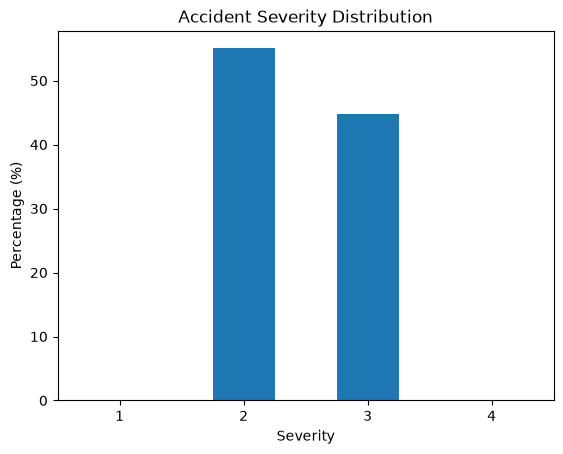

In [60]:
import matplotlib.pyplot as plt

severity_pct.plot(kind="bar")

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()

In [61]:
state_counts = clean["State"].value_counts()

print(state_counts)

State
CA    99272
OH      726
WV        2
Name: count, dtype: int64


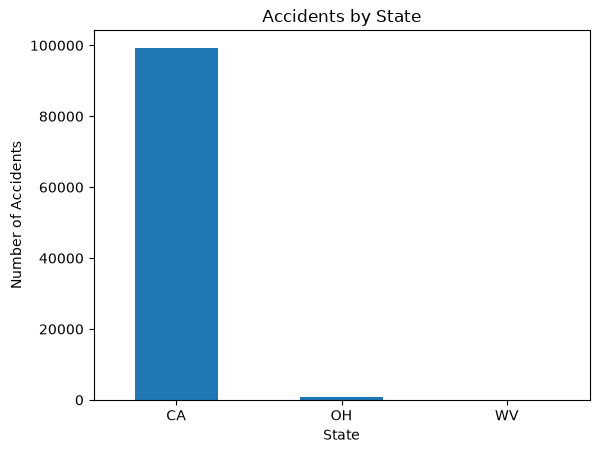

In [62]:
state_counts.plot(kind="bar")

plt.title("Accidents by State")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.show()

In [63]:
weather_counts = clean["Weather_Condition"].value_counts()

print(weather_counts.head(10))

Weather_Condition
Clear               58859
Overcast            10255
Mostly Cloudy        8829
Partly Cloudy        8260
Scattered Clouds     5684
Light Rain           3211
Haze                 2097
Fair                 1039
Rain                  829
Heavy Rain            202
Name: count, dtype: int64


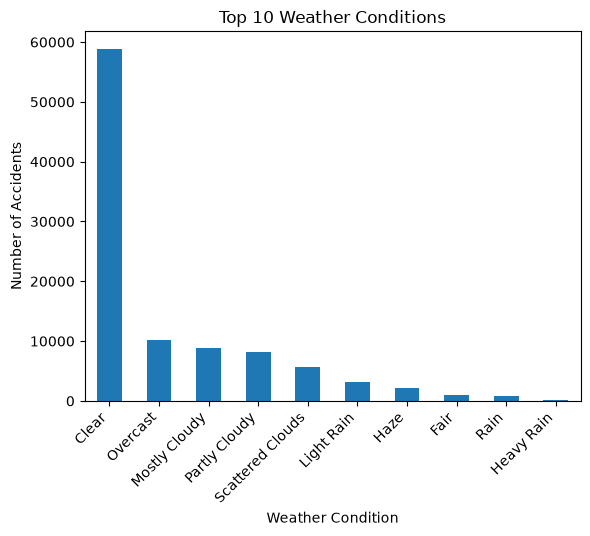

In [64]:
top_weather = weather_counts.head(10)

top_weather.plot(kind="bar")

plt.title("Top 10 Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")
plt.show()

In [65]:
weather_severity = clean.groupby("Weather_Condition")["Severity"].mean()

print(weather_severity.sort_values(ascending=False).head(10))

Weather_Condition
Blowing Sand               3.000000
Hail                       3.000000
Heavy Drizzle              3.000000
Partly Cloudy / Windy      3.000000
Light Rain / Windy         3.000000
Thunderstorm               3.000000
Thunder in the Vicinity    3.000000
Light Freezing Rain        3.000000
Light Freezing Fog         3.000000
Drizzle                    2.766667
Name: Severity, dtype: float64


In [66]:
weather_severity = clean.groupby("Weather_Condition")["Severity"].mean()

In [67]:
.sort_values(ascending=False).head(10)

SyntaxError: invalid syntax (1023668037.py, line 1)

In [68]:
weather_analysis = clean.groupby("Weather_Condition").agg(
    Accident_Count=("Severity", "count"),
    Average_Severity=("Severity", "mean")
)

print(weather_analysis.sort_values("Accident_Count", ascending=False).head(10))

                   Accident_Count  Average_Severity
Weather_Condition                                  
Clear                       58859          2.435617
Overcast                    10255          2.429449
Mostly Cloudy                8829          2.476158
Partly Cloudy                8260          2.501453
Scattered Clouds             5684          2.480296
Light Rain                   3211          2.477421
Haze                         2097          2.478779
Fair                         1039          2.316651
Rain                          829          2.496984
Heavy Rain                    202          2.564356


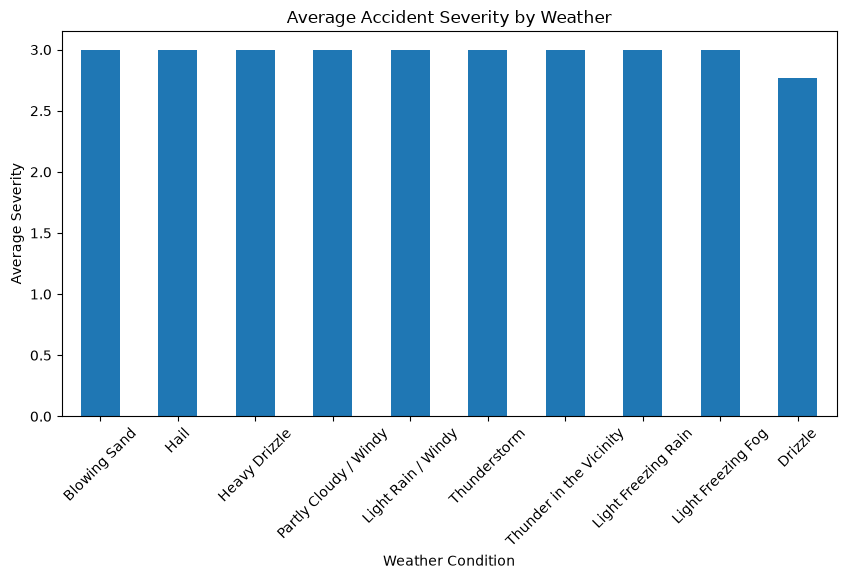

In [69]:
top_weather = weather_analysis.sort_values(
    "Average_Severity",
    ascending=False
).head(10)

top_weather["Average_Severity"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Accident Severity by Weather"
)

plt.xlabel("Weather Condition")
plt.ylabel("Average Severity")
plt.xticks(rotation=45)
plt.show()

In [70]:
state_severity = clean.groupby("State").agg(
    Accident_Count=("Severity", "count"),
    Average_Severity=("Severity", "mean")
)

print(state_severity.sort_values("Accident_Count", ascending=False))

       Accident_Count  Average_Severity
State                                  
CA              99272          2.449039
OH                726          2.322314
WV                  2          2.500000


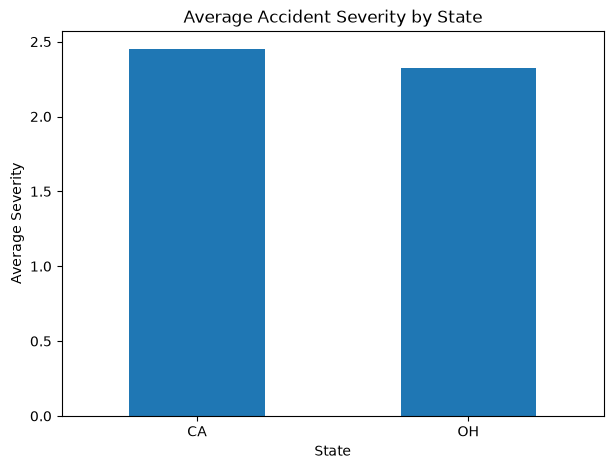

In [71]:
state_severity[state_severity["Accident_Count"] >= 100]["Average_Severity"].plot(
    kind="bar",
    figsize=(7, 5),
    title="Average Accident Severity by State"
)

plt.xlabel("State")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.show()

In [72]:
state_severity_counts = pd.crosstab(
    clean["State"],
    clean["Severity"]
)

print(state_severity_counts)

Severity   1      2      3   4
State                         
CA        96  54535  44609  32
OH         2    489    234   1
WV         0      1      1   0


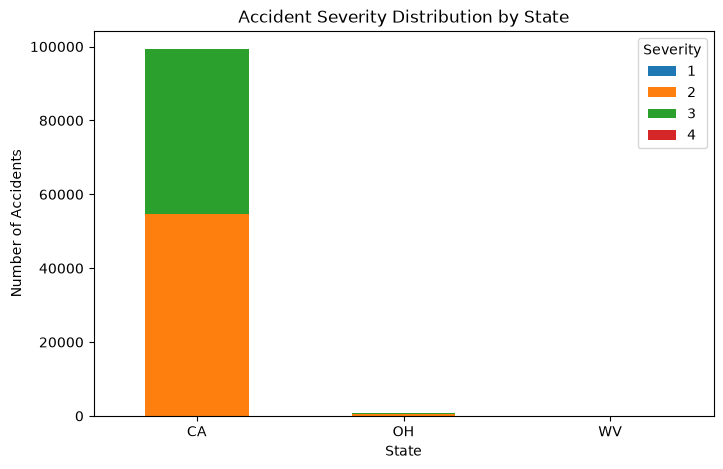

In [73]:
state_severity_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Accident Severity Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.show()

In [74]:
state_severity_pct = pd.crosstab(
    clean["State"],
    clean["Severity"],
    normalize="index"
) * 100

print(state_severity_pct.round(2))

Severity     1      2      3     4
State                             
CA        0.10  54.93  44.94  0.03
OH        0.28  67.36  32.23  0.14
WV        0.00  50.00  50.00  0.00


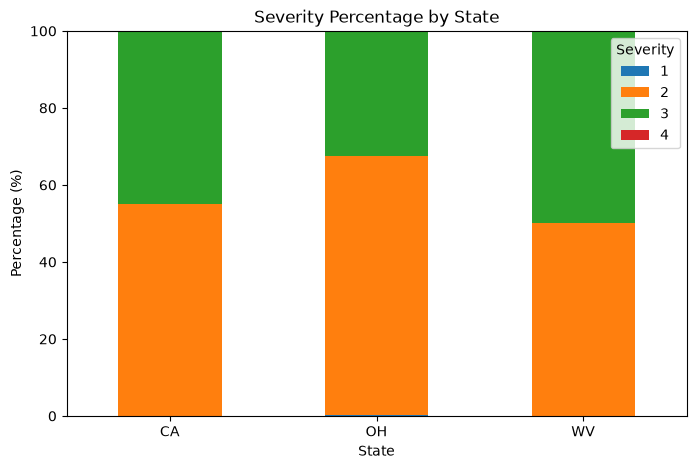

In [75]:
state_severity_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Severity Percentage by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.show()

In [76]:
clean["Hour"] = clean["Start_Time"].dt.hour

print(clean["Hour"].value_counts().sort_index())

Hour
0     2240
1     1895
2     1895
3     1507
4     1303
5     1516
6     1378
7     2196
8     3142
9     5291
10    7285
11    7910
12    6219
13    5137
14    5208
15    4707
16    5293
17    5035
18    6144
19    6722
20    7404
21    4970
22    3773
23    1830
Name: count, dtype: int64


In [77]:
hour_severity = clean.groupby("Hour")["Severity"].mean()

print(hour_severity)

Hour
0     2.460268
1     2.486544
2     2.498153
3     2.487724
4     2.506523
5     2.467018
6     2.511611
7     2.436703
8     2.474857
9     2.471366
10    2.448044
11    2.440834
12    2.448947
13    2.436247
14    2.442588
15    2.417251
16    2.410542
17    2.438729
18    2.434082
19    2.444362
20    2.455429
21    2.456338
22    2.437848
23    2.426776
Name: Severity, dtype: float64


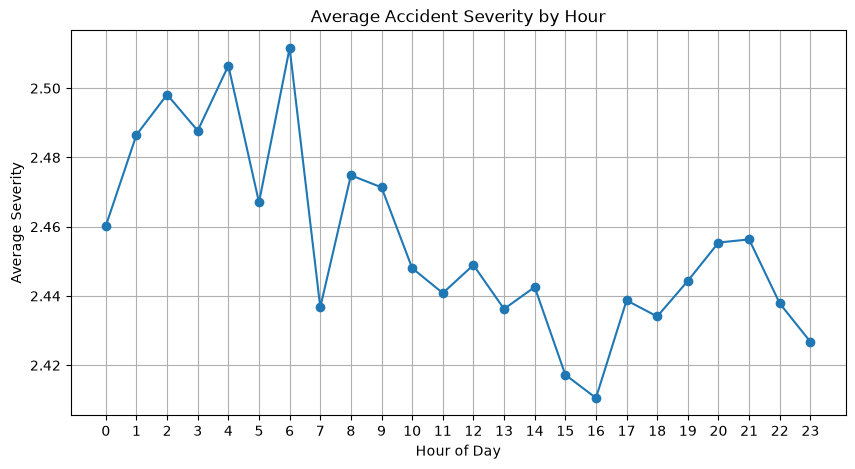

In [78]:
hour_severity.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Accident Severity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Severity")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [79]:
clean["Day"] = clean["Start_Time"].dt.day_name()

print(clean["Day"].value_counts())

Day
Thursday     18008
Wednesday    17438
Tuesday      16988
Friday       16393
Monday       15826
Saturday      7994
Sunday        7353
Name: count, dtype: int64


In [80]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = clean["Day"].value_counts().reindex(day_order)

print(day_counts)

Day
Monday       15826
Tuesday      16988
Wednesday    17438
Thursday     18008
Friday       16393
Saturday      7994
Sunday        7353
Name: count, dtype: int64


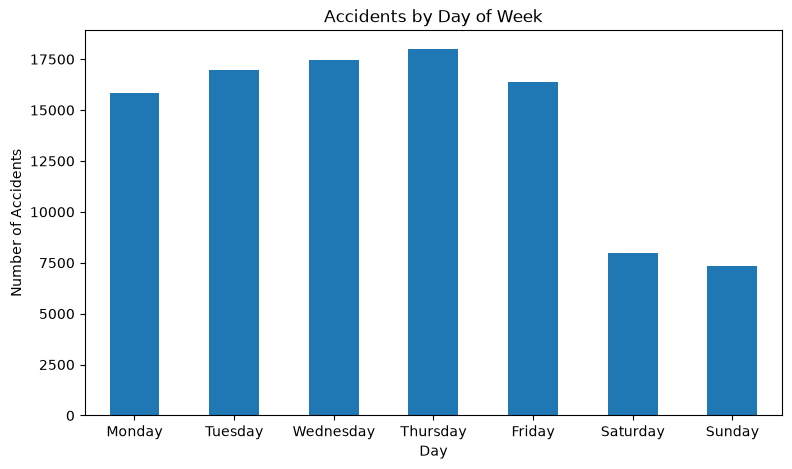

In [81]:
day_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.show()

In [82]:
day_severity = clean.groupby("Day")["Severity"].mean()

day_severity = day_severity.reindex(day_order)

print(day_severity)

Day
Monday       2.439656
Tuesday      2.433836
Wednesday    2.434626
Thursday     2.453687
Friday       2.455499
Saturday     2.484113
Sunday       2.462124
Name: Severity, dtype: float64


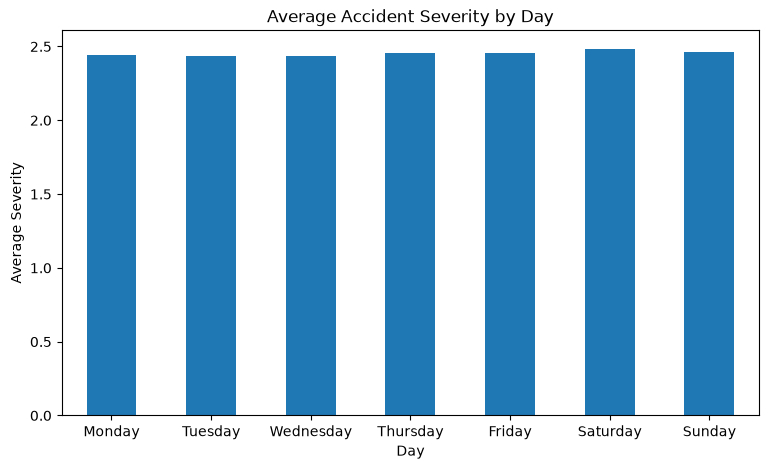

In [83]:
day_severity.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Accident Severity by Day")
plt.xlabel("Day")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.show()

In [84]:
day_hour_severity = pd.pivot_table(
    clean,
    values="Severity",
    index="Day",
    columns="Hour",
    aggfunc="mean"
)

day_hour_severity = day_hour_severity.reindex(day_order)

print(day_hour_severity)

Hour             0         1         2         3         4         5   \
Day                                                                     
Monday     2.505747  2.451923  2.496528  2.413934  2.528302  2.453333   
Tuesday    2.411924  2.509158  2.497835  2.408377  2.485294  2.390244   
Wednesday  2.491071  2.440529  2.484444  2.538462  2.500000  2.415584   
Thursday   2.416149  2.501650  2.510949  2.516129  2.480000  2.525510   
Friday     2.478947  2.474522  2.476868  2.529148  2.511494  2.444444   
Saturday   2.480226  2.575000  2.459184  2.519417  2.485830  2.516484   
Sunday     2.440367  2.486928  2.556291  2.498054  2.539419  2.481481   

Hour             6         7         8         9   ...        14        15  \
Day                                                ...                       
Monday     2.469565  2.435530  2.464041  2.499425  ...  2.418133  2.409910   
Tuesday    2.450704  2.404040  2.463768  2.444871  ...  2.390274  2.419825   
Wednesday  2.434783  2.401840 

In [85]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    day_hour_severity,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Average Accident Severity by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day")
plt.show()

NameError: name 'sns' is not defined

<Figure size 1400x600 with 0 Axes>

In [86]:
import seaborn as sns

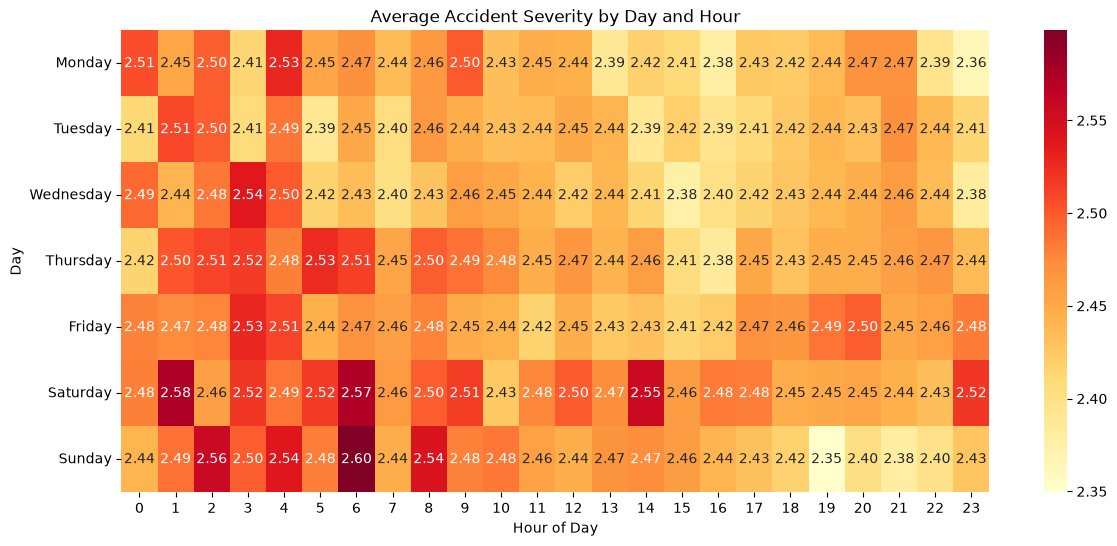

In [87]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    day_hour_severity,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Average Accident Severity by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day")
plt.show()

In [88]:
signal_severity = clean.groupby("Traffic_Signal")["Severity"].mean()

print(signal_severity)

Traffic_Signal
False    2.482402
True     2.161978
Name: Severity, dtype: float64


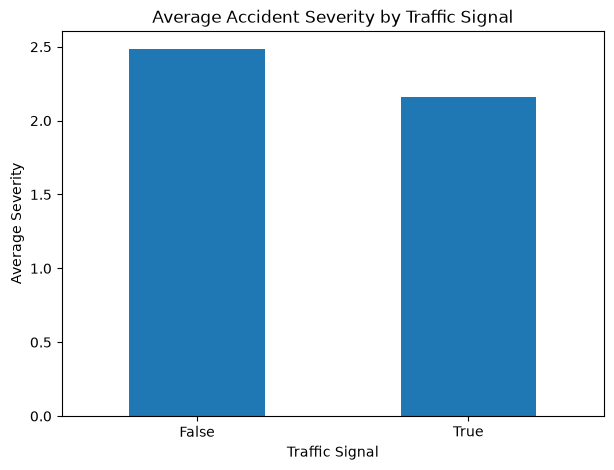

In [89]:
signal_severity.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Accident Severity by Traffic Signal")
plt.xlabel("Traffic Signal")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.show()

In [90]:
junction_severity = clean.groupby("Junction")["Severity"].mean()

print(junction_severity)

Junction
False    2.432084
True     2.585777
Name: Severity, dtype: float64


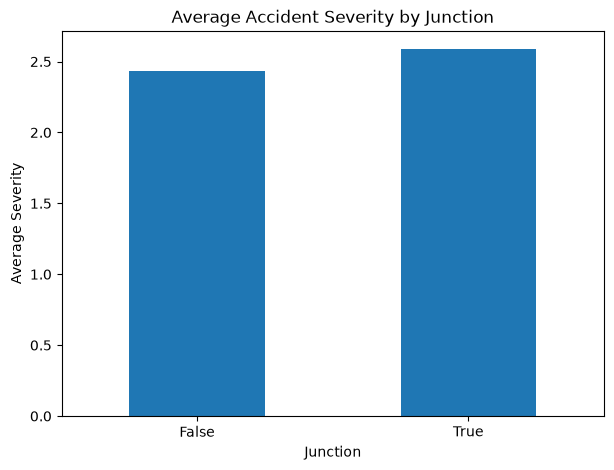

In [91]:
junction_severity.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Accident Severity by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.show()

In [92]:
road_severity = clean.groupby("Road_Type")["Severity"].mean()

print(road_severity)

KeyError: 'Road_Type'

In [93]:
print(clean.columns.tolist())

['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Duration_min', 'Hour', 'Day']


In [94]:
crossing_severity = clean.groupby("Crossing")["Severity"].mean()

print(crossing_severity)

Crossing
False    2.468758
True     2.150717
Name: Severity, dtype: float64


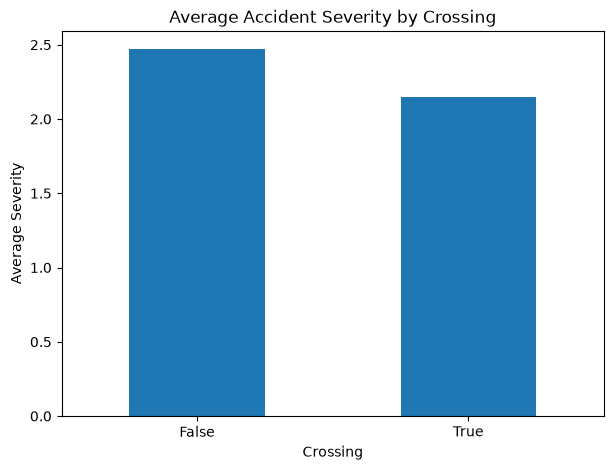

In [95]:
crossing_severity.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Accident Severity by Crossing")
plt.xlabel("Crossing")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.show()

In [96]:
railway_severity = clean.groupby("Railway")["Severity"].mean()

print(railway_severity)

Railway
False    2.447052
True     2.531696
Name: Severity, dtype: float64


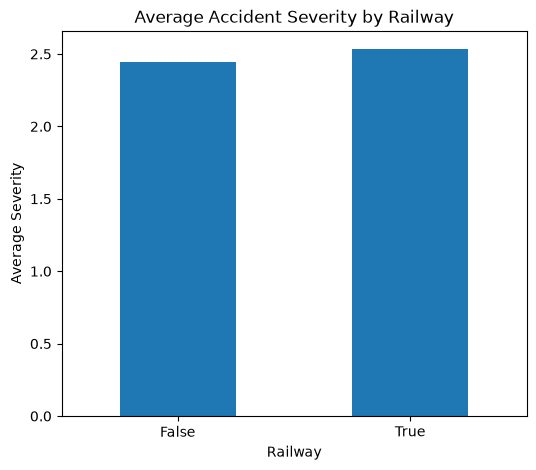

In [97]:
railway_severity.plot(
    kind="bar",
    figsize=(6, 5)
)

plt.title("Average Accident Severity by Railway")
plt.xlabel("Railway")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.show()

In [98]:
weather_severity = clean.groupby("Weather_Condition")["Severity"].mean()

print(weather_severity.sort_values(ascending=False))

Weather_Condition
Blowing Sand                    3.000000
Hail                            3.000000
Heavy Drizzle                   3.000000
Partly Cloudy / Windy           3.000000
Light Rain / Windy              3.000000
Thunderstorm                    3.000000
Thunder in the Vicinity         3.000000
Light Freezing Rain             3.000000
Light Freezing Fog              3.000000
Drizzle                         2.766667
Shallow Fog                     2.750000
Widespread Dust                 2.727273
Snow                            2.714286
Light Drizzle                   2.622222
Light Thunderstorms and Rain    2.615385
Rain Showers                    2.583333
Heavy Rain                      2.564356
Partly Cloudy                   2.501453
Thunderstorms and Rain          2.500000
Rain                            2.496984
Scattered Clouds                2.480296
Haze                            2.478779
Light Rain                      2.477421
Mostly Cloudy                   2.47615

In [99]:
weather_counts = clean["Weather_Condition"].value_counts()

print(weather_counts)

Weather_Condition
Clear                           58859
Overcast                        10255
Mostly Cloudy                    8829
Partly Cloudy                    8260
Scattered Clouds                 5684
Light Rain                       3211
Haze                             2097
Fair                             1039
Rain                              829
Heavy Rain                        202
Fog                               159
Cloudy                            142
Light Snow                        116
Smoke                              79
Light Drizzle                      45
Mist                               35
Drizzle                            30
Patches of Fog                     15
Light Thunderstorms and Rain       13
Fair / Windy                       12
Rain Showers                       12
Widespread Dust                    11
Light Freezing Drizzle             10
Thunderstorms and Rain             10
Shallow Fog                         8
Snow                            

In [100]:
common_weather = weather_counts[weather_counts >= 100].index

weather_severity_common = weather_severity[common_weather].sort_values(
    ascending=False
)

print(weather_severity_common)

Weather_Condition
Heavy Rain          2.564356
Partly Cloudy       2.501453
Rain                2.496984
Scattered Clouds    2.480296
Haze                2.478779
Light Rain          2.477421
Mostly Cloudy       2.476158
Clear               2.435617
Overcast            2.429449
Light Snow          2.422414
Cloudy              2.338028
Fair                2.316651
Fog                 2.314465
Name: Severity, dtype: float64


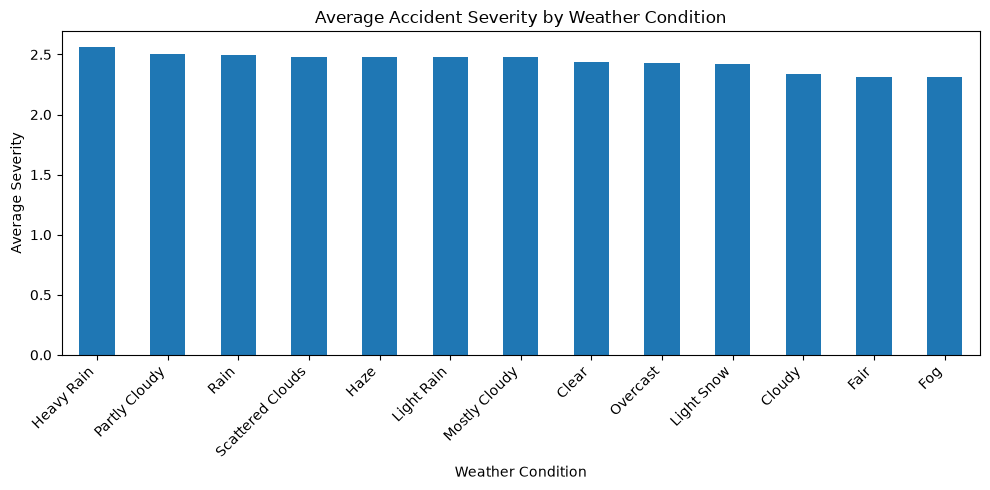

In [101]:
weather_severity_common.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Accident Severity by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Severity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [102]:
visibility_severity = clean.groupby("Severity")["Visibility(mi)"].mean()

print(visibility_severity)

Severity
1    9.576531
2    9.343673
3    9.359306
4    9.151515
Name: Visibility(mi), dtype: float64


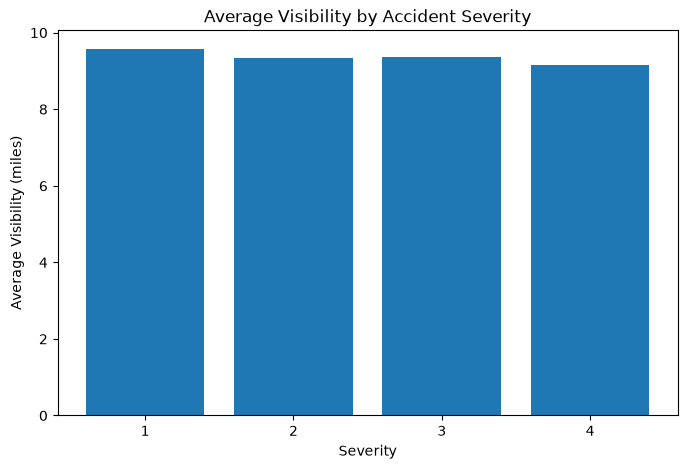

In [103]:
plt.figure(figsize=(8, 5))

plt.bar(
    visibility_severity.index.astype(str),
    visibility_severity.values
)

plt.title("Average Visibility by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Average Visibility (miles)")
plt.show()

In [104]:
temperature_severity = clean.groupby("Severity")["Temperature(F)"].mean()

print(temperature_severity)

Severity
1    64.876531
2    66.380343
3    66.945259
4    62.924242
Name: Temperature(F), dtype: float64


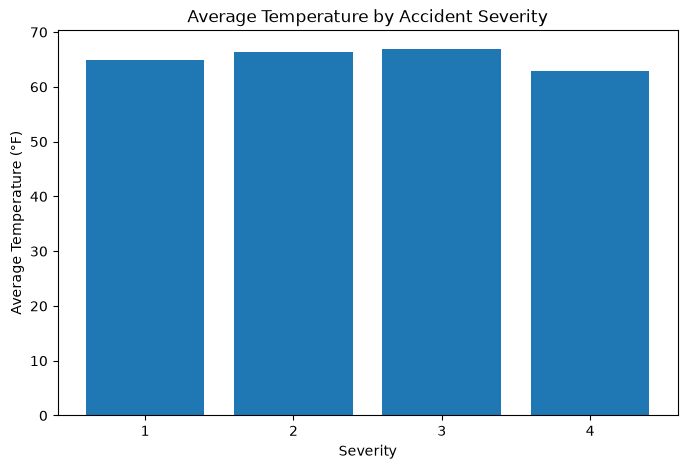

In [105]:
plt.figure(figsize=(8, 5))

plt.bar(
    temperature_severity.index.astype(str),
    temperature_severity.values
)

plt.title("Average Temperature by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Average Temperature (°F)")
plt.show()

In [106]:
humidity_severity = clean.groupby("Severity")["Humidity(%)"].mean()

print(humidity_severity)

Severity
1    61.020408
2    59.658301
3    60.044577
4    66.484848
Name: Humidity(%), dtype: float64


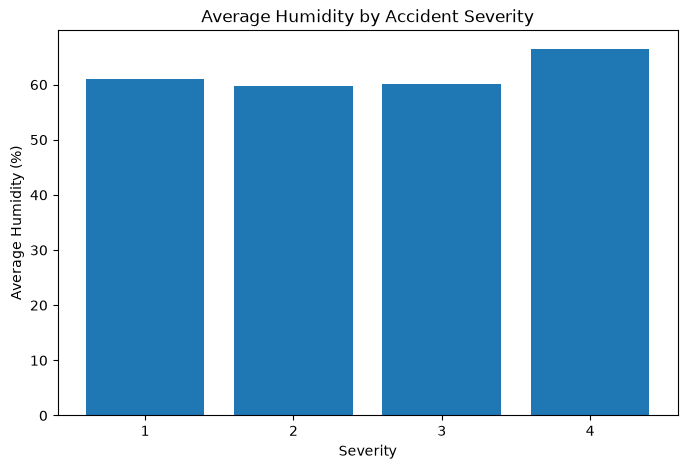

In [107]:
plt.figure(figsize=(8, 5))

plt.bar(
    humidity_severity.index.astype(str),
    humidity_severity.values
)

plt.title("Average Humidity by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Average Humidity (%)")
plt.show()

In [108]:
pressure_severity = clean.groupby("Severity")["Pressure(in)"].mean()

print(pressure_severity)

Severity
1    29.989898
2    29.960455
3    29.964921
4    29.977879
Name: Pressure(in), dtype: float64


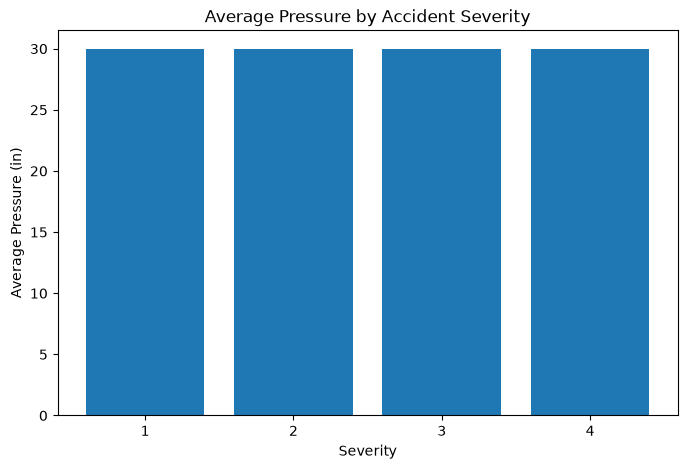

In [109]:
plt.figure(figsize=(8, 5))

plt.bar(
    pressure_severity.index.astype(str),
    pressure_severity.values
)

plt.title("Average Pressure by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Average Pressure (in)")
plt.show()

In [110]:
wind_speed_severity = clean.groupby("Severity")["Wind_Speed(mph)"].mean()

print(wind_speed_severity)

Severity
1    8.013265
2    7.736542
3    7.806048
4    7.545455
Name: Wind_Speed(mph), dtype: float64


In [111]:
wind_direction_severity = clean.groupby("Severity")["Wind_Direction"].count()

print(wind_direction_severity)

Severity
1       98
2    55025
3    44844
4       33
Name: Wind_Direction, dtype: int64


In [112]:
wind_direction_severity = clean.groupby(
    "Wind_Direction"
)["Severity"].mean().sort_values(ascending=False)

print(wind_direction_severity)

Wind_Direction
WSW         2.502916
ENE         2.486915
SW          2.477030
West        2.471239
WNW         2.470524
NE          2.468567
SSW         2.466719
East        2.462430
NNE         2.452509
Variable    2.450471
Calm        2.443656
NW          2.423967
North       2.423055
ESE         2.421915
South       2.420375
SE          2.401298
NNW         2.392694
SSE         2.379421
E           2.336364
CALM        2.333333
N           2.276423
VAR         2.232558
S           2.197674
W           2.180000
Name: Severity, dtype: float64


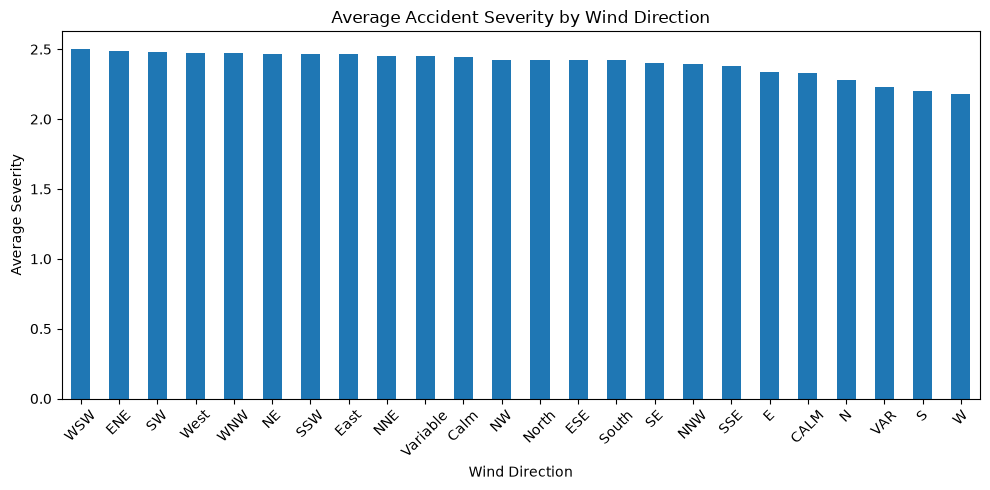

In [113]:
plt.figure(figsize=(10, 5))

wind_direction_severity.plot(kind="bar")

plt.title("Average Accident Severity by Wind Direction")
plt.xlabel("Wind Direction")
plt.ylabel("Average Severity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [114]:
junction_severity = clean.groupby("Junction")["Severity"].mean()

print(junction_severity)

Junction
False    2.432084
True     2.585777
Name: Severity, dtype: float64


In [115]:
junction_severity = junction_severity.sort_values(ascending=False)

print(junction_severity)

Junction
True     2.585777
False    2.432084
Name: Severity, dtype: float64


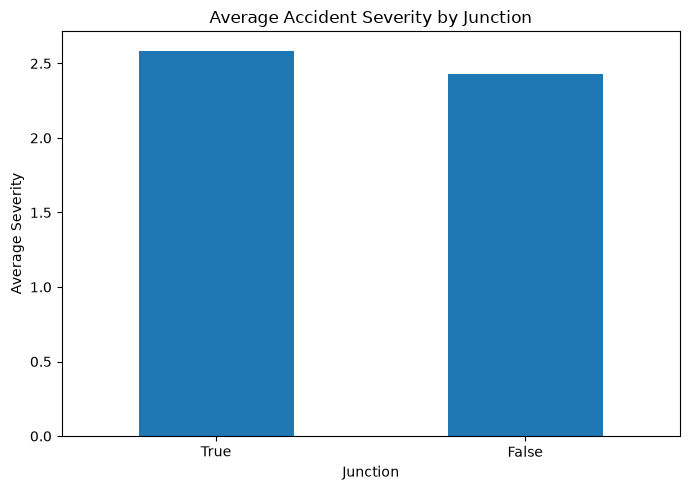

In [116]:
plt.figure(figsize=(7, 5))

junction_severity.plot(kind="bar")

plt.title("Average Accident Severity by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [117]:
traffic_signal_severity = clean.groupby("Traffic_Signal")["Severity"].mean()

print(traffic_signal_severity)

Traffic_Signal
False    2.482402
True     2.161978
Name: Severity, dtype: float64


In [118]:
traffic_signal_severity = traffic_signal_severity.sort_values(ascending=False)

print(traffic_signal_severity)

Traffic_Signal
False    2.482402
True     2.161978
Name: Severity, dtype: float64


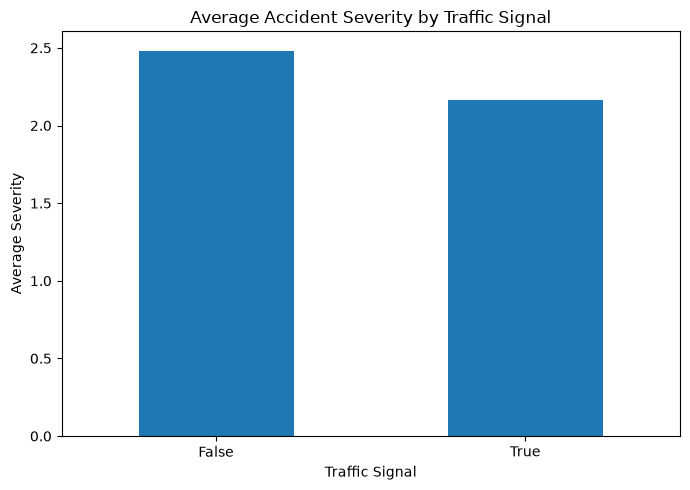

In [119]:
plt.figure(figsize=(7, 5))

traffic_signal_severity.plot(kind="bar")

plt.title("Average Accident Severity by Traffic Signal")
plt.xlabel("Traffic Signal")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [120]:
stop_severity = clean.groupby("Stop")["Severity"].mean()

print(stop_severity)

Stop
False    2.459669
True     2.112214
Name: Severity, dtype: float64


In [121]:
stop_severity = stop_severity.sort_values(ascending=False)

print(stop_severity)

Stop
False    2.459669
True     2.112214
Name: Severity, dtype: float64


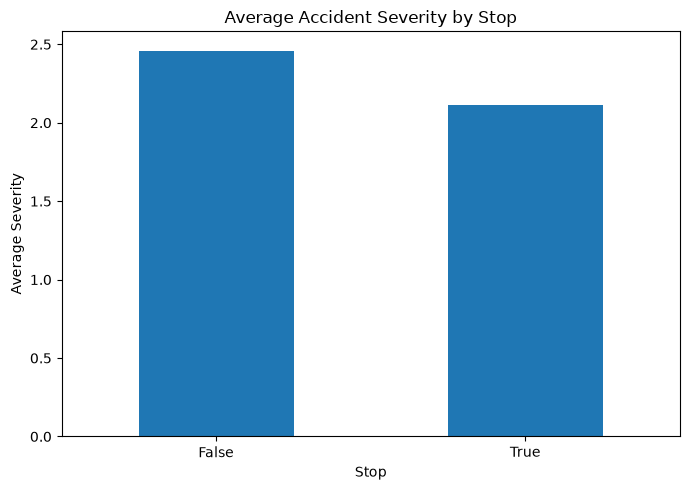

In [122]:
plt.figure(figsize=(7, 5))

stop_severity.plot(kind="bar")

plt.title("Average Accident Severity by Stop")
plt.xlabel("Stop")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [123]:
junction_severity = clean.groupby("Junction")["Severity"].mean()

print(junction_severity)

Junction
False    2.432084
True     2.585777
Name: Severity, dtype: float64


In [124]:
junction_severity = junction_severity.sort_values(ascending=False)

print(junction_severity)

Junction
True     2.585777
False    2.432084
Name: Severity, dtype: float64


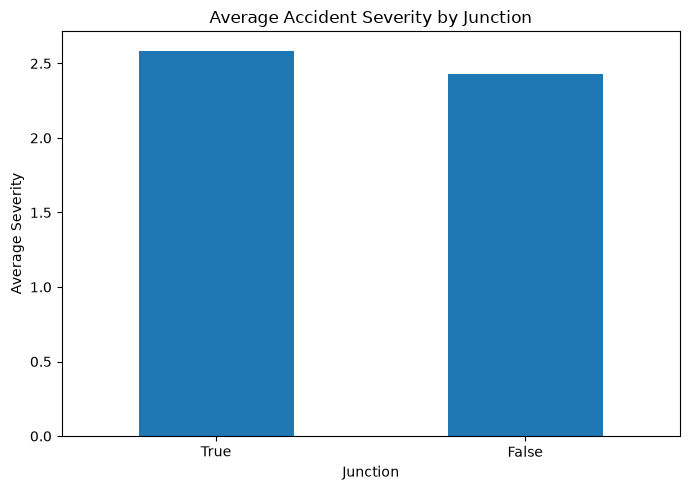

In [125]:
plt.figure(figsize=(7, 5))

junction_severity.plot(kind="bar")

plt.title("Average Accident Severity by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [126]:
severity_count = clean["Severity"].value_counts().sort_index()

print(severity_count)

Severity
1       98
2    55025
3    44844
4       33
Name: count, dtype: int64


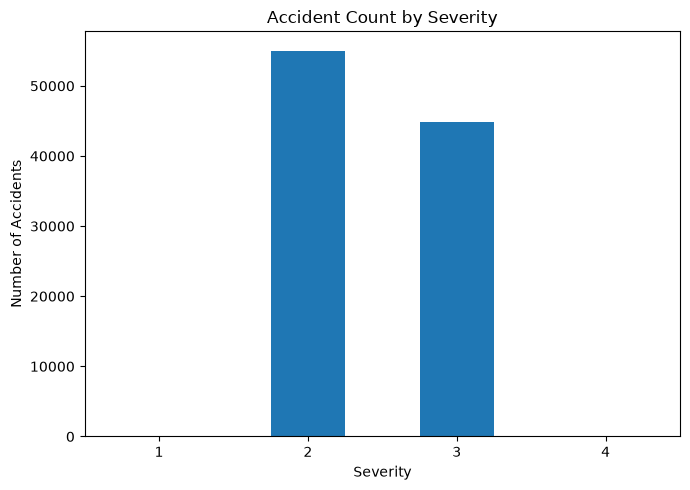

In [127]:
plt.figure(figsize=(7, 5))

severity_count.plot(kind="bar")

plt.title("Accident Count by Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [128]:
temperature_severity = clean.groupby("Severity")["Temperature(F)"].mean()

print(temperature_severity)

Severity
1    64.876531
2    66.380343
3    66.945259
4    62.924242
Name: Temperature(F), dtype: float64


In [129]:
temperature_severity = temperature_severity.sort_values(ascending=False)

print(temperature_severity)

Severity
3    66.945259
2    66.380343
1    64.876531
4    62.924242
Name: Temperature(F), dtype: float64


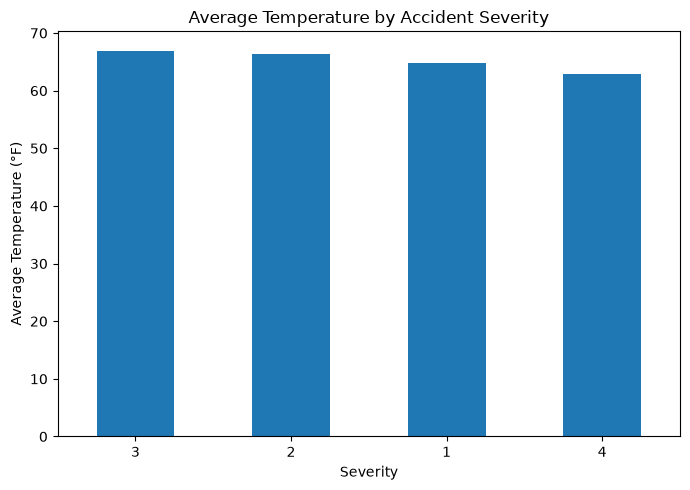

In [130]:
plt.figure(figsize=(7, 5))

temperature_severity.plot(kind="bar")

plt.title("Average Temperature by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Average Temperature (°F)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [131]:
visibility_severity = clean.groupby("Severity")["Visibility(mi)"].mean()

print(visibility_severity)

Severity
1    9.576531
2    9.343673
3    9.359306
4    9.151515
Name: Visibility(mi), dtype: float64


In [132]:
visibility_severity = visibility_severity.sort_values(ascending=False)

print(visibility_severity)

Severity
1    9.576531
3    9.359306
2    9.343673
4    9.151515
Name: Visibility(mi), dtype: float64


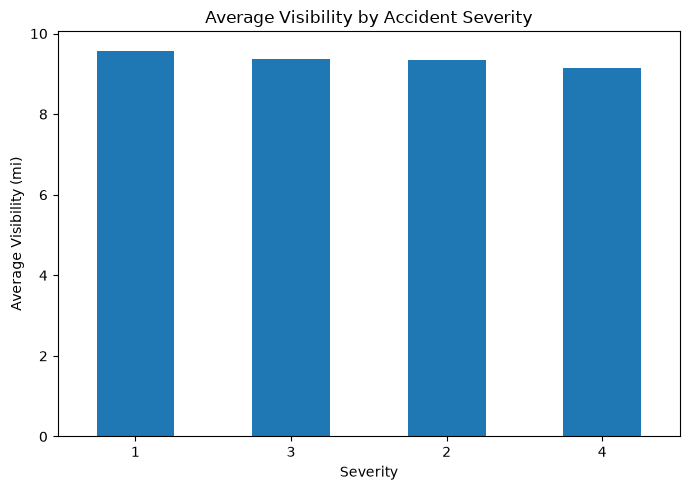

In [133]:
plt.figure(figsize=(7, 5))

visibility_severity.plot(kind="bar")

plt.title("Average Visibility by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Average Visibility (mi)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [134]:
weather_count = clean["Weather_Condition"].value_counts().head(15)

print(weather_count)

Weather_Condition
Clear               58859
Overcast            10255
Mostly Cloudy        8829
Partly Cloudy        8260
Scattered Clouds     5684
Light Rain           3211
Haze                 2097
Fair                 1039
Rain                  829
Heavy Rain            202
Fog                   159
Cloudy                142
Light Snow            116
Smoke                  79
Light Drizzle          45
Name: count, dtype: int64


In [135]:
weather_severity = clean.groupby("Weather_Condition")["Severity"].mean()

weather_severity = weather_severity.sort_values(ascending=False)

print(weather_severity.head(15))

Weather_Condition
Blowing Sand                    3.000000
Hail                            3.000000
Heavy Drizzle                   3.000000
Partly Cloudy / Windy           3.000000
Light Rain / Windy              3.000000
Thunderstorm                    3.000000
Thunder in the Vicinity         3.000000
Light Freezing Rain             3.000000
Light Freezing Fog              3.000000
Drizzle                         2.766667
Shallow Fog                     2.750000
Widespread Dust                 2.727273
Snow                            2.714286
Light Drizzle                   2.622222
Light Thunderstorms and Rain    2.615385
Name: Severity, dtype: float64


In [136]:
weather_analysis = clean.groupby("Weather_Condition").agg(
    Accident_Count=("Severity", "count"),
    Average_Severity=("Severity", "mean")
)

weather_analysis = weather_analysis.sort_values(
    "Accident_Count",
    ascending=False
)

print(weather_analysis.head(15))

                   Accident_Count  Average_Severity
Weather_Condition                                  
Clear                       58859          2.435617
Overcast                    10255          2.429449
Mostly Cloudy                8829          2.476158
Partly Cloudy                8260          2.501453
Scattered Clouds             5684          2.480296
Light Rain                   3211          2.477421
Haze                         2097          2.478779
Fair                         1039          2.316651
Rain                          829          2.496984
Heavy Rain                    202          2.564356
Fog                           159          2.314465
Cloudy                        142          2.338028
Light Snow                    116          2.422414
Smoke                          79          2.291139
Light Drizzle                  45          2.622222


In [137]:
weather_analysis = clean.groupby("Weather_Condition").agg(
    Accident_Count=("Severity", "count"),
    Average_Severity=("Severity", "mean")
)

weather_analysis = weather_analysis.sort_values(
    "Accident_Count",
    ascending=False
)

print(weather_analysis.head(15))

                   Accident_Count  Average_Severity
Weather_Condition                                  
Clear                       58859          2.435617
Overcast                    10255          2.429449
Mostly Cloudy                8829          2.476158
Partly Cloudy                8260          2.501453
Scattered Clouds             5684          2.480296
Light Rain                   3211          2.477421
Haze                         2097          2.478779
Fair                         1039          2.316651
Rain                          829          2.496984
Heavy Rain                    202          2.564356
Fog                           159          2.314465
Cloudy                        142          2.338028
Light Snow                    116          2.422414
Smoke                          79          2.291139
Light Drizzle                  45          2.622222


In [138]:
correlation = clean.select_dtypes(include="number").corr()

print(correlation["Severity"].sort_values(ascending=False))

Severity           1.000000
Start_Lng          0.040003
Temperature(F)     0.022248
Pressure(in)       0.010905
Wind_Speed(mph)    0.009069
Humidity(%)        0.008461
Visibility(mi)     0.003679
Distance(mi)      -0.000610
Duration_min      -0.001469
Hour              -0.023419
Start_Lat         -0.127796
Name: Severity, dtype: float64


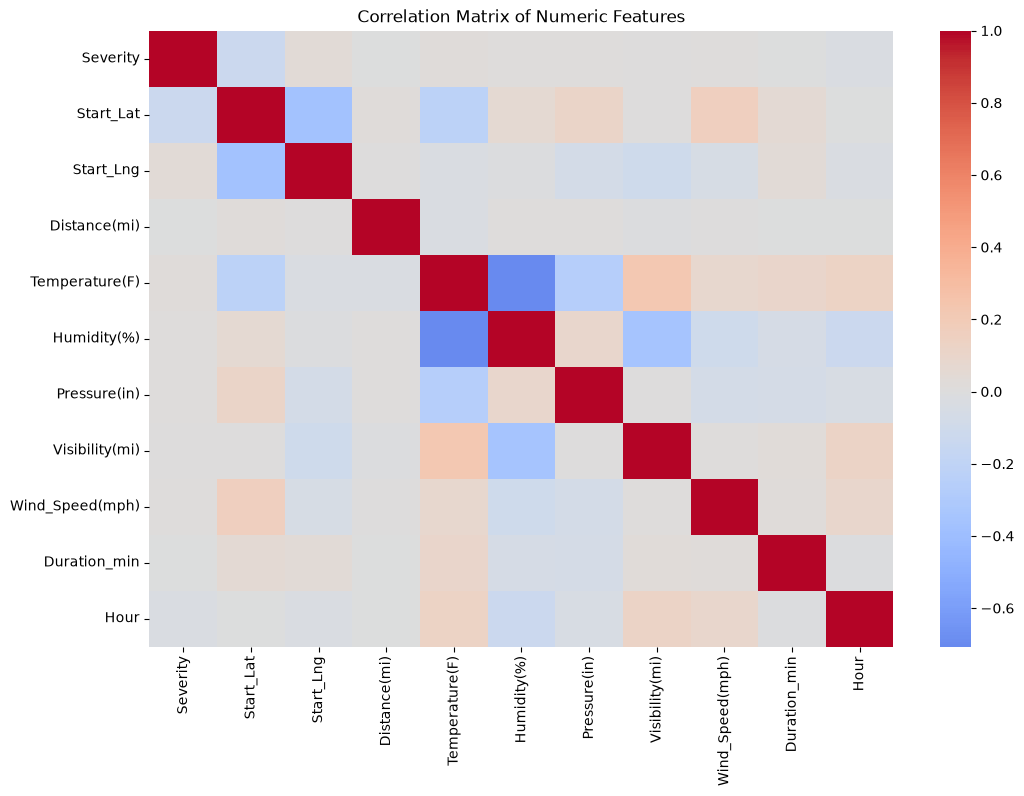

In [139]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [140]:
clean.to_pickle("clean_data.pkl")